## Introduction

## Time-Series Momentum in Action

We begin with the simplest possible example: one asset.

At the end of each month, we compute the asset’s trailing 12-month return.  
If that trailing return is positive, the signal is long. If it is negative, the signal is short.

Formally, define the signal at month-end \(t\) as

$$
s_t = \operatorname{sign}(r_{t-12:t})
$$

To avoid lookahead bias, the position held during month \(t\) is based on the signal formed at the end of month \(t-1\). Therefore, the strategy return in month \(t\) is

$$
r^{\mathrm{TSMOM}}_t = s_{t-1} \cdot r_t
$$

This first example is not meant to fully establish the paper’s cross-asset result. Its goal is to make the mechanics of time-series momentum intuitive before moving to the diversified multi-asset case.

### SPY, month-end

We use **SPY** with `load_yahoo_close` (cached under `data/daily/`). The next cells: daily range check → **month-end** prices and returns → **12m trailing return** and **sign** signal.


In [1]:
import pandas as pd
from helpers.data_utils import load_yahoo_close, daily_to_month_end, month_end_to_returns
from helpers.signal_utils import trailing_return, sign_signal
from helpers.backtest_utils import position_from_signal, strategy_returns, position_counts, position_summary, cumulative_returns, drawdown, compare_perf_stats
from helpers.plot_utils import plot_tsmom_diagnostics

ticker = "SPY"
# Use the cached CSV by default; set refresh=True only when you want to update.
px = load_yahoo_close(ticker, refresh=False)
px.tail()

Loaded SPY from cache: data/daily/SPY_adj_close.csv | rows=8350


Date
2026-03-26    645.090027
2026-03-27    634.090027
2026-03-30    631.969971
2026-03-31    650.340027
2026-04-01    655.239990
Name: Close, dtype: float64

In [2]:
print(px.index.min(), px.index.max(), len(px))

1993-01-29 00:00:00 2026-04-01 00:00:00 8350


In [3]:
px_m = daily_to_month_end(px)
r_m = month_end_to_returns(px_m)
trailing_12m = trailing_return(r_m, 12)
signal = sign_signal(trailing_12m)

pd.concat([px_m, r_m, trailing_12m, signal], axis=1).tail(15)

,month_end_price,asset_return,trailing_12m,signal
Date,,,,
2025-02-28,585.683960,-0.012695,0.184463,1.0
2025-03-31,553.050110,-0.055719,0.083048,1.0
2025-04-30,548.255005,-0.008670,0.118765,1.0
2025-05-31,582.710144,0.062845,0.131827,1.0
2025-06-30,612.653381,0.051386,0.149435,1.0
2025-07-31,626.763733,0.023032,0.161839,1.0
2025-08-31,639.624573,0.020519,0.158608,1.0
2025-09-30,662.408264,0.035620,0.175194,1.0
2025-10-31,678.198364,0.023837,0.214041,1.0


### Lag and strategy returns

Match the math above: **`position_from_signal(..., lag=1)`** implements $s_{t-1}$; **`strategy_returns`** multiplies by month-$t$ **asset return** to get $r^{\mathrm{TSMOM}}_t$. The table adds position mix and the full panel.


In [4]:
position = position_from_signal(signal, lag=1)
strategy_r = strategy_returns(position, r_m)

out = pd.concat(
    [px_m, r_m, trailing_12m, signal, position, strategy_r],
    axis=1
).dropna()

counts = position_counts(out["position"])
summary = position_summary(out["position"])

print("Position counts:")
print(counts)
print()
print(f"Long fraction:  {summary['long_frac']:.2%}")
print(f"Short fraction: {summary['short_frac']:.2%}")
print(f"Flat fraction:  {summary['flat_frac']:.2%}")

out.tail(15)

Position counts:
position
-1.0     70
 1.0    317
Name: count, dtype: int64

Long fraction:  81.91%
Short fraction: 18.09%
Flat fraction:  0.00%


,month_end_price,asset_return,trailing_12m,signal,position,strategy_return
Date,,,,,,
2025-02-28,585.683960,-0.012695,0.184463,1.0,1.0,-0.012695
2025-03-31,553.050110,-0.055719,0.083048,1.0,1.0,-0.055719
2025-04-30,548.255005,-0.008670,0.118765,1.0,1.0,-0.008670
2025-05-31,582.710144,0.062845,0.131827,1.0,1.0,0.062845
2025-06-30,612.653381,0.051386,0.149435,1.0,1.0,0.051386
2025-07-31,626.763733,0.023032,0.161839,1.0,1.0,0.023032
2025-08-31,639.624573,0.020519,0.158608,1.0,1.0,0.020519
2025-09-30,662.408264,0.035620,0.175194,1.0,1.0,0.035620
2025-10-31,678.198364,0.023837,0.214041,1.0,1.0,0.023837


### Results

**Table**: performance stats for **buy-and-hold** vs **TSMOM** on the same months. **Next cell**: cumulative paths, position, and drawdowns via `plot_tsmom_diagnostics`.


In [5]:
asset_cum = cumulative_returns(out["asset_return"], name="asset_cum")
strategy_cum = cumulative_returns(out["strategy_return"], name="strategy_cum")

asset_dd = drawdown(asset_cum)
strategy_dd = drawdown(strategy_cum)

stats = compare_perf_stats({
    "Asset": out["asset_return"],
    "TSMOM": out["strategy_return"]
})

stats

,Asset,TSMOM
CAGR,0.103694,0.098995
Ann. Mean,0.110222,0.105883
Ann. Vol,0.148785,0.149048
Sharpe,0.740809,0.710390
Max Drawdown,-0.507848,-0.363045
Hit Rate,0.651163,0.651163


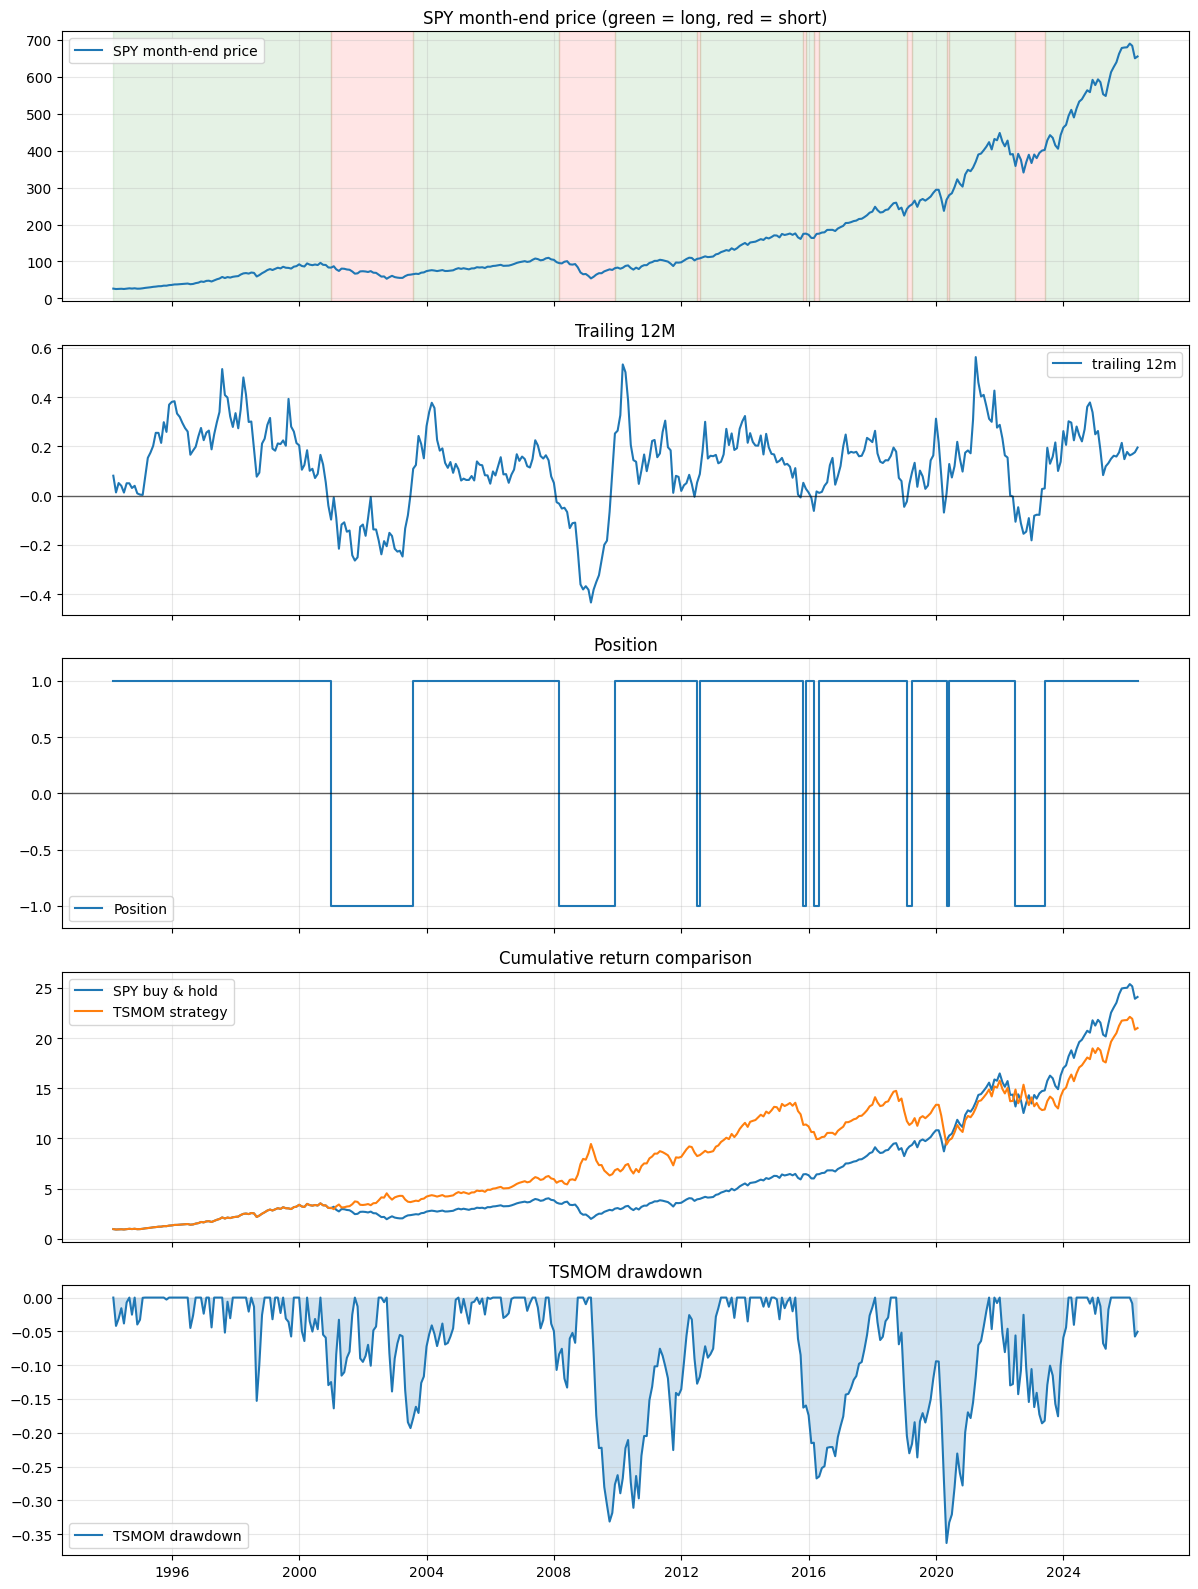

In [6]:
plot_tsmom_diagnostics(out, ticker=ticker)

This first illustration ignores transaction costs, slippage, financing details, and futures-specific roll mechanics. Its purpose is only to show the basic time-series momentum rule on a single asset.